In [18]:
from pathlib import Path
import pandas as pd

REPO_ROOT = Path('..').resolve()

EXPERIMENTS = {
    'Base YOLOv8':          REPO_ROOT / 'results/quality_filter_nofilter_metrics.csv',
    'VAE Probabilistic Filter': REPO_ROOT / 'results/quality_filter_metrics_crops.csv',
    'VAE Reconstruction': REPO_ROOT / 'results/vae_baseline_metrics.csv',
}

RIVERS  = ['combined', 'kitwanga', 'bear']
METRICS = ['AP50', 'Precision', 'Recall']

def load(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df[df['class'] == 'all']

frames = {name: load(path) for name, path in EXPERIMENTS.items()}

In [3]:
# Per-river summary
rows = []
for river in RIVERS:
    for name, df in frames.items():
        means = df[df['river'] == river][METRICS].mean()
        rows.append({'River': river.capitalize(), 'Experiment': name,
                     'mAP50': means['AP50'], 'Precision': means['Precision'],
                     'Recall': means['Recall']})

summary = (pd.DataFrame(rows)
             .set_index(['River', 'Experiment'])
             .round(4))
summary

mAP50  Precision  Recall
River    Experiment                                   
Combined No Filter           0.2191     0.4658  0.4649
         VAE Quality Filter  0.2215     0.4782  0.4591
         VAE Reconstruction  0.0281     0.0368  0.1572
Kitwanga No Filter           0.1058     0.4998  0.4958
         VAE Quality Filter  0.1114     0.5173  0.4897
         VAE Reconstruction  0.0315     0.3495  0.0676
Bear     No Filter           0.3035     0.3515  0.3593
         VAE Quality Filter  0.3003     0.3486  0.3494
         VAE Reconstruction  0.0321     0.0380  0.2016

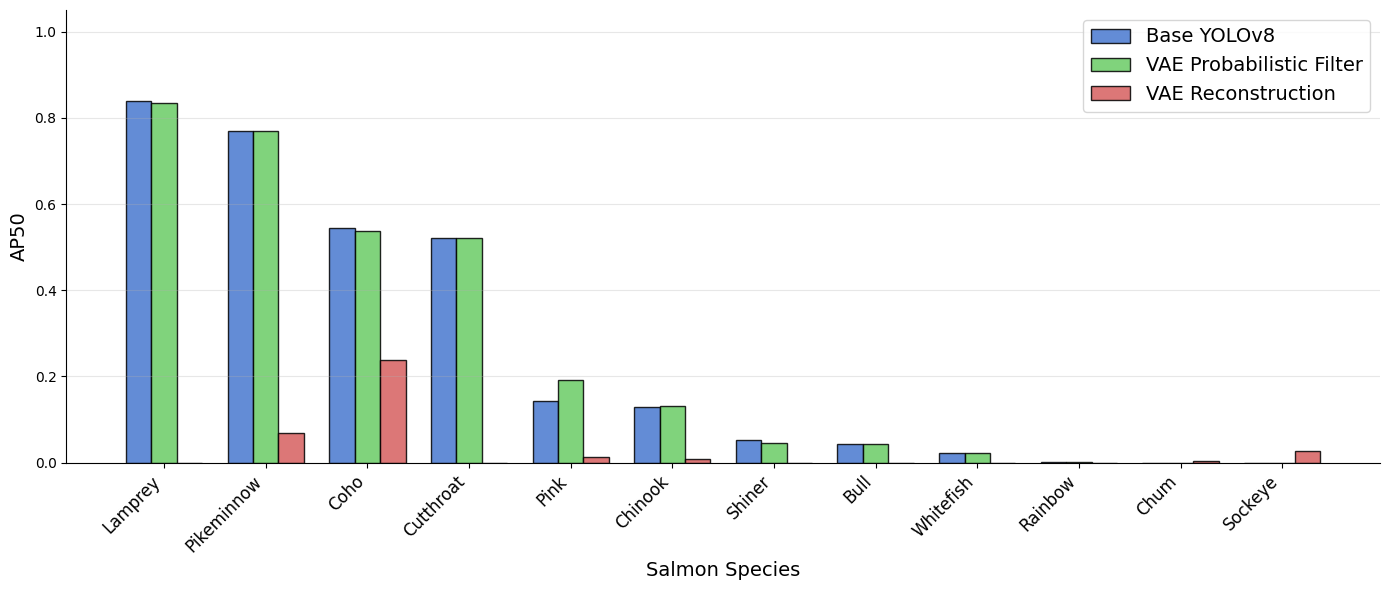

In [24]:
import matplotlib.pyplot as plt
import numpy as np

def load_species(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df[df['class'] != 'all']

species_frames = {name: load_species(path) for name, path in EXPERIMENTS.items()}

# Average AP50 over seeds for combined river
plot_df = pd.DataFrame({
    name: df[df['river'] == 'combined'].groupby('class')['AP50'].mean()
    for name, df in species_frames.items()
})

# Drop species with zero AP50 across all treatments
plot_df = plot_df[(plot_df > 0).any(axis=1)]
plot_df = plot_df.sort_values('Base YOLOv8', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#4878CF', '#6ACC65', '#D65F5F']
n     = len(EXPERIMENTS)
width = 0.25
x     = np.arange(len(plot_df))

for i, (name, color) in enumerate(zip(EXPERIMENTS.keys(), colors)):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, plot_df[name], width, label=name, color=color, edgecolor="black", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right', fontsize=12)
ax.set_xlabel('Salmon Species', fontsize=14)
ax.set_ylabel('AP50',fontsize=14)
ax.set_ylim(0, 1.05)
ax.legend(fontsize=14)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ExperimentSummary.png", dpi=300)
plt.show()

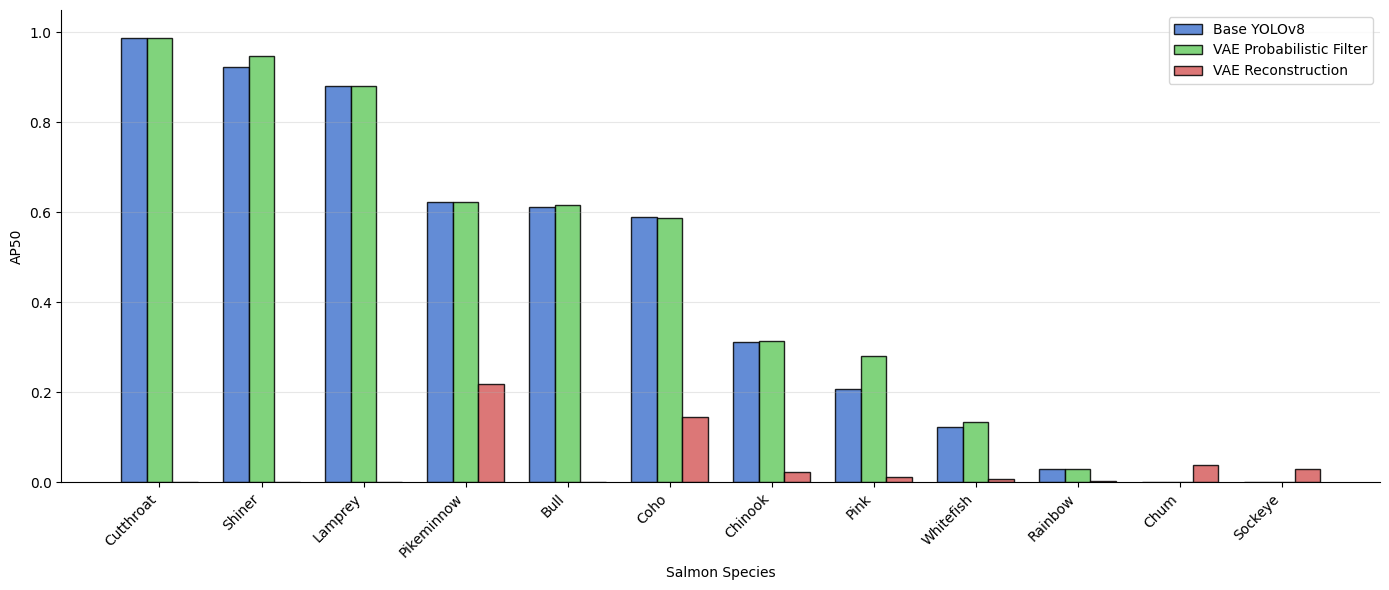

In [20]:
import matplotlib.pyplot as plt
import numpy as np

def load_species(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df[df['class'] != 'all']

species_frames = {name: load_species(path) for name, path in EXPERIMENTS.items()}

# Average AP50 over seeds for combined river
plot_df = pd.DataFrame({
    name: df[df['river'] == 'combined'].groupby('class')['Precision'].mean()
    for name, df in species_frames.items()
})

# Drop species with zero AP50 across all treatments
plot_df = plot_df[(plot_df > 0).any(axis=1)]
plot_df = plot_df.sort_values('Base YOLOv8', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#4878CF', '#6ACC65', '#D65F5F']
n     = len(EXPERIMENTS)
width = 0.25
x     = np.arange(len(plot_df))

for i, (name, color) in enumerate(zip(EXPERIMENTS.keys(), colors)):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, plot_df[name], width, label=name, color=color, edgecolor="black", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
ax.set_xlabel('Salmon Species')
ax.set_ylabel('AP50')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ExperimentSummaryPrecision.png", dpi=300)
plt.show()

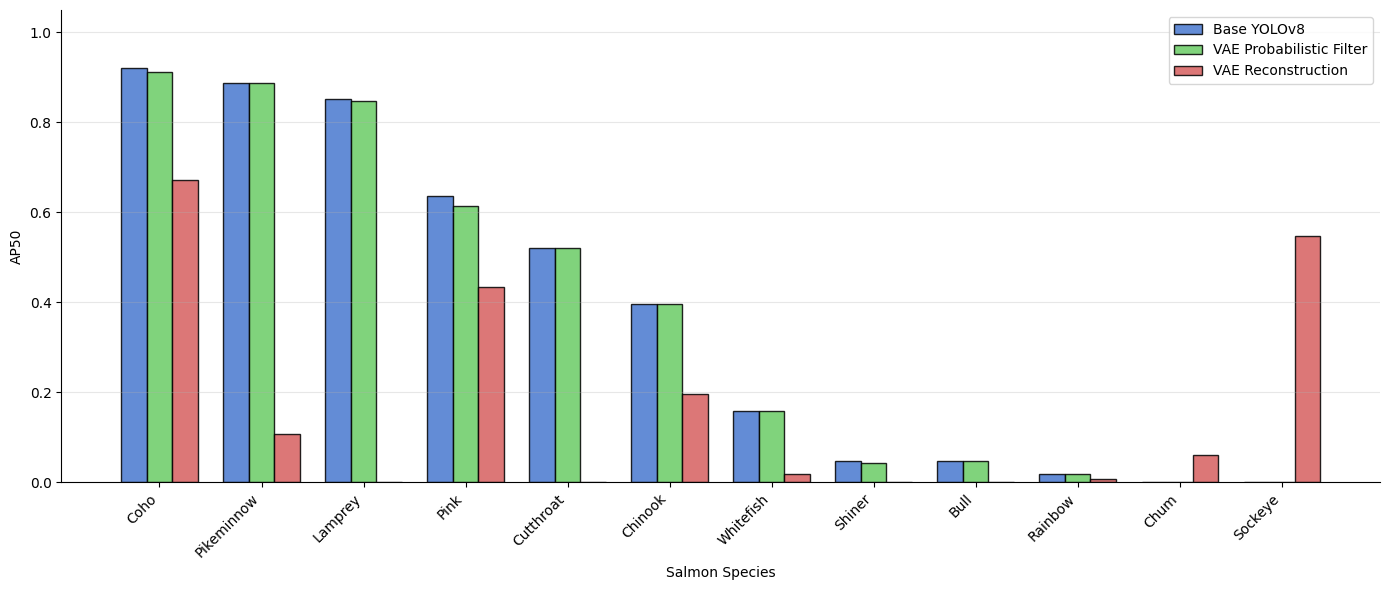

In [21]:
import matplotlib.pyplot as plt
import numpy as np

def load_species(path):
    df = pd.read_csv(path)
    df.columns = df.columns.str.strip()
    return df[df['class'] != 'all']

species_frames = {name: load_species(path) for name, path in EXPERIMENTS.items()}

# Average AP50 over seeds for combined river
plot_df = pd.DataFrame({
    name: df[df['river'] == 'combined'].groupby('class')['Recall'].mean()
    for name, df in species_frames.items()
})

# Drop species with zero AP50 across all treatments
plot_df = plot_df[(plot_df > 0).any(axis=1)]
plot_df = plot_df.sort_values('Base YOLOv8', ascending=False)

fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#4878CF', '#6ACC65', '#D65F5F']
n     = len(EXPERIMENTS)
width = 0.25
x     = np.arange(len(plot_df))

for i, (name, color) in enumerate(zip(EXPERIMENTS.keys(), colors)):
    offset = (i - n / 2 + 0.5) * width
    ax.bar(x + offset, plot_df[name], width, label=name, color=color, edgecolor="black", alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=45, ha='right')
ax.set_xlabel('Salmon Species')
ax.set_ylabel('AP50')
ax.set_ylim(0, 1.05)
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig("ExperimentSummaryRecall.png", dpi=300)
plt.show()

In [5]:
# Overall summary (mean across all rivers and seeds)
overall_rows = []
for name, df in frames.items():
    means = df[METRICS].mean()
    overall_rows.append({'Experiment': name, 'mAP50': means['AP50'],
                         'Precision': means['Precision'], 'Recall': means['Recall']})

overall = pd.DataFrame(overall_rows).set_index('Experiment').round(4)
overall

,mAP50,Precision,Recall
Experiment,,,
No Filter,0.2095,0.4390,0.4400
VAE Quality Filter,0.2111,0.4480,0.4327
VAE Reconstruction,0.0306,0.1414,0.1421
